## Step 1: Import libraries

In [45]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,confusion_matrix

## Step 2: Import Dataset

In [11]:
wine_data=load_wine()

In [12]:
wine_data_df=pd.DataFrame(wine_data.data,columns=wine_data.feature_names)
wine_data_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [13]:
print(wine_data.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [14]:
wine_data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

## Step 3: Data Understanding

In [15]:
wine_data_df.shape

(178, 13)

In [16]:
wine_data_df.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

In [17]:
wine_data_df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [18]:
wine_data_df.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
dtype: object

## Step 4: Data Preparation

In [24]:
wine_data_df["Target"]=wine_data.target
wine_data_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [26]:
X=wine_data_df.drop(labels=["Target"],axis=1)
X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


y=wine_data_df["Target"]
y

In [22]:
y.value_counts()

Target
1    71
0    59
2    48
Name: count, dtype: int64

In [28]:
from matplotlib import pyplot as plt

([<matplotlib.patches.Wedge object at 0x000002306446C490>, <matplotlib.patches.Wedge object at 0x000002306446C130>, <matplotlib.patches.Wedge object at 0x0000023063C96170>], [Text(0.3467331079629081, 1.0544553816271138, 'Class 1'), Text(-1.0197938047684203, -0.438315634852271, 'Class 0'), Text(0.7349378075375981, -0.8318451893542623, 'Class 2')], [Text(0.19054702329493148, 0.5794754799932789, '39.9%'), Text(-0.5604272260439065, -0.24087615969359033, '33.1%'), Text(0.40388474107922057, -0.45714014910459455, '27.0%')])


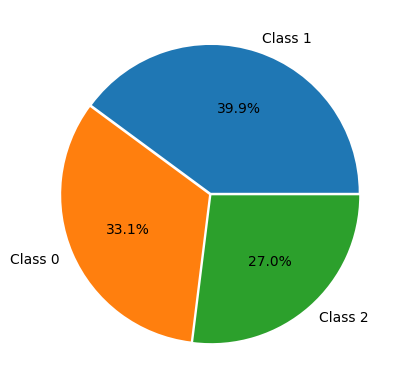

In [34]:
print(plt.pie(y.value_counts(),labels=["Class 1","Class 0","Class 2"],explode=[0.01,0.01,0.01],autopct='%1.1f%%'))

In [74]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=10)

## Step 5: Model Building

In [75]:
dt_moedl=DecisionTreeClassifier(criterion='gini',max_depth=5,class_weight={0: 2, 1: 3, 2:1})

## Step 6: Model Training

In [76]:
%%time
dt_moedl.fit(X_train,y_train)

CPU times: total: 0 ns
Wall time: 3.4 ms


,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: 2, 1: 3, 2: 1}"


## Step 7: Model Testing 

### Testing with training data

In [56]:
y_pred_Train=dt_moedl.predict(X_train)
y_pred_Train

array([2, 0, 1, 2, 1, 0, 1, 2, 2, 2, 2, 1, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0,
       0, 1, 2, 0, 2, 1, 2, 2, 1, 1, 2, 2, 1, 1, 0, 2, 2, 2, 2, 1, 0, 1,
       1, 1, 1, 1, 1, 2, 0, 1, 0, 2, 0, 0, 1, 2, 1, 2, 1, 0, 1, 1, 1, 0,
       0, 0, 2, 1, 1, 1, 0, 2, 1, 2, 2, 0, 0, 1, 0, 0, 0, 2, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 0, 0,
       1, 2, 0, 1, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 2, 1, 2, 1, 2, 0, 0,
       0, 2, 1, 1, 0, 0, 1, 0, 2, 0])

### Testing with testing data

In [57]:
y_pred_test=dt_moedl.predict(X_test)
y_pred_test

array([1, 2, 1, 2, 0, 0, 1, 0, 0, 2, 1, 1, 0, 1, 2, 0, 1, 0, 0, 1, 0, 0,
       2, 1, 1, 0, 1, 1, 1, 0, 1, 2, 0, 2, 0, 2])

## Step 8: Model Evaluation

### Training data metrics

In [58]:
print(classification_report(y_train,y_pred_Train))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        47
           1       1.00      1.00      1.00        57
           2       1.00      0.97      0.99        38

    accuracy                           0.99       142
   macro avg       0.99      0.99      0.99       142
weighted avg       0.99      0.99      0.99       142



In [59]:
print(confusion_matrix(y_train,y_pred_Train))

[[47  0  0]
 [ 0 57  0]
 [ 1  0 37]]


### Testing data metrics

In [60]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       1.00      1.00      1.00        14
           2       1.00      0.80      0.89        10

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



In [61]:
print(confusion_matrix(y_test,y_pred_test))

[[12  0  0]
 [ 0 14  0]
 [ 2  0  8]]


## Standard Scaler - optimization technique for fast processing and better accuracy

In [62]:
from sklearn.preprocessing import StandardScaler

In [63]:
ss=StandardScaler()

In [67]:
scaled_X=pd.DataFrame(ss.fit_transform(X=X),columns=wine_data.feature_names)
scaled_X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.274310,-0.930179,1.142811,-1.392758,-1.231206,-0.021952
174,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893
175,0.332758,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.549108,-0.422075,2.224236,-1.612125,-1.485445,0.280575
176,0.209232,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.354888,-0.229346,1.834923,-1.568252,-1.400699,0.296498


In [77]:
X_train,X_test,y_train,y_test=train_test_split(scaled_X,y,test_size=0.2,stratify=y,random_state=10)

In [78]:
dt_moedl=DecisionTreeClassifier(criterion='gini',max_depth=5,class_weight={0: 2, 1: 3, 2:1})

In [79]:
%%time
dt_moedl.fit(X_train,y_train)

CPU times: total: 31.2 ms
Wall time: 3.76 ms


,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: 2, 1: 3, 2: 1}"


In [80]:
y_pred_Train=dt_moedl.predict(X_train)
y_pred_Train

array([2, 0, 1, 2, 1, 0, 1, 2, 2, 2, 2, 1, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0,
       0, 1, 2, 0, 2, 1, 2, 2, 1, 1, 2, 2, 1, 1, 0, 2, 2, 2, 2, 1, 0, 1,
       1, 1, 1, 1, 1, 2, 0, 1, 0, 2, 0, 0, 1, 2, 1, 2, 1, 0, 1, 1, 1, 0,
       0, 0, 2, 1, 1, 1, 0, 2, 1, 2, 2, 0, 0, 1, 0, 0, 0, 2, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 0, 0,
       1, 2, 0, 1, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 2, 1, 2, 1, 2, 0, 0,
       0, 2, 1, 1, 0, 0, 1, 0, 2, 0])

In [81]:
y_pred_test=dt_moedl.predict(X_test)
y_pred_test

array([1, 2, 1, 2, 0, 0, 1, 0, 2, 2, 2, 1, 0, 0, 2, 0, 1, 0, 0, 1, 0, 0,
       2, 1, 1, 0, 1, 0, 1, 0, 1, 2, 0, 2, 0, 2])

In [82]:
print(classification_report(y_train,y_pred_Train))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        47
           1       1.00      1.00      1.00        57
           2       1.00      0.97      0.99        38

    accuracy                           0.99       142
   macro avg       0.99      0.99      0.99       142
weighted avg       0.99      0.99      0.99       142



In [83]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89        12
           1       1.00      0.79      0.88        14
           2       0.90      0.90      0.90        10

    accuracy                           0.89        36
   macro avg       0.90      0.90      0.89        36
weighted avg       0.91      0.89      0.89        36

